<h1 style="text-align: center;">
    🌌 Creating Data Streams
</h1>

This notebook demonstrates how to create evolving distributions with `streamgen` using parameter schedules.

---

## 📄 Table of Contents

1. [🌳 Sampling tree](#🌳-sampling-tree)
2. [⚙️ Parameter schedules](#⚙️-parameter-schedules)
3. [🫂 Putting everything together](#🫂-putting-everything-together)

In [1]:
import itables
import numpy as np
from numpy.random import Generator
import pandas as pd
import seaborn as sns
from rich import print

from streamgen import visualizations
from streamgen.parameter.store import ParameterStore
from streamgen.samplers.tree import SamplingTree

SEED = 42
rng = np.random.default_rng(SEED)

itables.init_notebook_mode(all_interactive=False)

## 🌳 Sampling tree

We will re-use our time-series example from [examples/time series classification/01-static-distributions.ipynb](./01-static-distributions.ipynb):

In [2]:
# ➡️ transforms and generators
def background(signal_, signal_length: int, offset: float, strength: float, *, rng: Generator) -> np.ndarray:  # noqa: D103, ANN001, ARG001
    return rng.normal(offset, strength, signal_length)


def ramp(signal: np.ndarray, height: float, length: int, *, rng: Generator) -> np.ndarray:  # noqa: D103
    ramp_signal = np.zeros(len(signal))
    ramp_start = rng.choice(range(len(signal) - length))
    ramp_signal[ramp_start : ramp_start + length] = np.linspace(0.0, height, length)
    return signal + ramp_signal


def step(signal: np.ndarray, length: int, kernel_size: int, *, rng: Generator) -> np.ndarray:  # noqa: D103
    step_signal = np.zeros(len(signal))
    step_start = rng.choice(range(len(signal) - length))
    step_signal[step_start : step_start + length] = 1.0
    kernel = np.ones(kernel_size) / kernel_size
    step_signal = np.convolve(step_signal, kernel, mode="same")
    return signal + step_signal


# ⚙️ scoped parameter
params = {
    "background": {
        "signal_length": 256,
        "offset": 0.0,
        "strength": 0.1,
    },
    "ramp": {
        "height": 1.0,
        "length": 128,
    },
    "step": {
        "length": 128,
        "kernel_size": 10,
    },
}

# 🎲🌳 tree of transformations
tree = SamplingTree(
    [
        background,
        {
            "background": "background",
            "ramp": [ramp, "ramp"],
            "step": [step, "step"],
        },
    ],
    params,
    rng=rng
)

print(tree)

🌳
➡️ `background(offset=0.0, signal_length=256, strength=0.1)`
╰── 🪴 `branching_node()`
    ├── 🏷️ `background`
    ├── ➡️ `ramp(height=1.0, length=128)`
    │   ╰── 🏷️ `ramp`
    ╰── ➡️ `step(kernel_size=10, length=128)`
        ╰── 🏷️ `step`

## ⚙️ Parameter schedules

The tree we defined currently represents a static distribution, since the parameters that influence **how** the signals are constructed don't change over time.

If we want to model evolving distributions, we either need to change the **parameters** or **topology** of the tree over time. In this notebook, we will focus on scheduling the parameters.

![parameter schedule](../../docs/images/parameter_schedule.png)

`streamgen` has its own `Parameter` class, which represents a named variable that can change over time as defined by its **schedule**.

A `schedule` of a variable is simply an `Iterable` of values.
Additionally, you can define what happens when a schedule is exhausted via a parameters `strategy`.

In the previous example, we used simple nested dictionaries to set parameters via name-value pairs. Behind the scenes, the `SamplingTree` class converts this dictionary to a `ParameterStore` object, which is a container for `Parameter` objects. When you want to set the schedule and update strategy of your parameters, you need to define a `ParameterDict` as a value.

Lets create schedules for our example parameters:

In [3]:
params = ParameterStore(
    {
        "background": {
            "signal_length": 256,  # parameters don't need to have a schedule
            "offset": {"schedule": [0.0, 0.2, 0.5]},  # if only a schedule is defined, the first element will be used as the value
            "strength": {
                "schedule": [0.1, 0.4],
                "strategy": "cycle",  # cycle the schedule when it is exhausted. The default is holding the last value
            },
        },
        "ramp": {
            "height": {"schedule": [0.9, 0.8, 0.7]},
            "length": {"schedule": [128, 64, 32]},
        },
        "step": {
            "length": {"value": 128},
            "kernel_size": {"schedule": [1, 10, 20]},
        },
    },
)

print(params)

{
    'background.offset': 0.0,
    'background.signal_length': 256,
    'background.strength': 0.1,
    'ramp.height': 0.9,
    'ramp.length': 128,
    'step.kernel_size': 1,
    'step.length': 128
}

In [4]:
# 🆙 updating parameters
params.update()

print(params)

{
    'background.offset': 0.2,
    'background.signal_length': 256,
    'background.strength': 0.4,
    'ramp.height': 0.8,
    'ramp.length': 64,
    'step.kernel_size': 10,
    'step.length': 128
}

`ParameterStore`s can also be initialized from `pandas.DataFrame`s 🐼:

In [5]:
df = pd.DataFrame(
    {
        "background.signal_length": 256,
        "background.offset": [0.0, 0.2, 0.5],
        "background.strength": [0.1, 0.2, 0.4],
        "ramp.height": [0.9, 0.8, 0.7],
        "ramp.length": [128, 64, 32],
        "step.length": 128,
        "step.kernel_size": [1, 10, 20],
    },
)

itables.show(df, scrollx=True)

c:\Users\hundgeburth\AppData\Local\pypoetry\Cache\virtualenvs\streamgen-WTmPm9Y--py3.11\Lib\site-packages\itables\typing.py:203: SyntaxWarning: These arguments are not documented in ITableOptions: {'scrollx'}. You can silence this warning by setting `itables.options.warn_on_undocumented_option=False`. If you believe ITableOptions should be updated, please make a PR or open an issue at https://github.com/mwouts/itables
  warnings.warn(
c:\Users\hundgeburth\AppData\Local\pypoetry\Cache\virtualenvs\streamgen-WTmPm9Y--py3.11\Lib\site-packages\itables\typing.py:203: SyntaxWarning: These arguments are not documented in DTForITablesOptions: {'scrollx'}. You can silence this warning by setting `itables.options.warn_on_undocumented_option=False`. If you believe ITableOptions should be updated, please make a PR or open an issue at https://github.com/mwouts/itables
  warnings.warn(


Loading ITables v2.5.2 from the init_notebook_mode cell... (need help?)


In [6]:
params = ParameterStore.from_dataframe(df)

print(params)

{
    'background.offset': 0.0,
    'background.signal_length': 256,
    'background.strength': 0.1,
    'ramp.height': 0.9,
    'ramp.length': 128,
    'step.kernel_size': 1,
    'step.length': 128
}

🖼️ `Parameter`s and `ParameterStore`s can also be plotted using functions in `streamgen.visualizations`

In [7]:
visualizations.plot_parameter_store_widget(params, num_values=3)

> 🥲 Unfortunately, ipywidgets are not rendered in the hosted documentation, so we include a screenshot of the widget for reference:

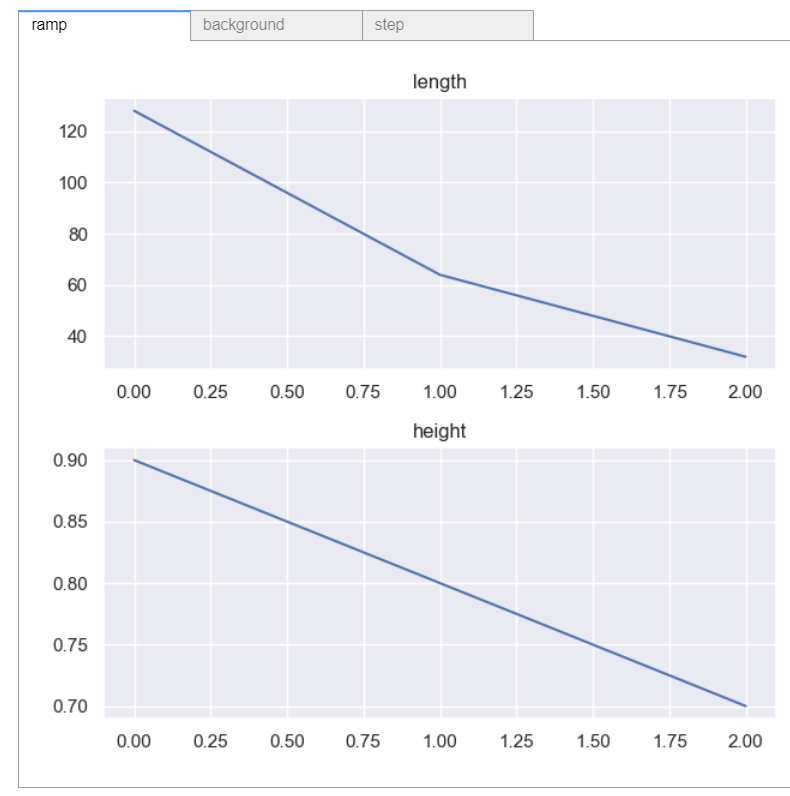

# 🫂 Putting everything together

With those two concepts in place, we can define and sample from dynamic distributions:

In [8]:
%matplotlib notebook
# 🎲🌳 tree of transformations
tree = SamplingTree(
    [
        background,
        {
            "background": "background",
            "ramp": [ramp, "ramp"],
            "step": [step, "step"],
        },
    ],
    params,
    rng=rng
)

# 🌌 simulate three experiences and collect 16 samples for each experience
experiences = []
for idx in range(3):
    print(f"Experience #{idx+1}")
    experiences.append(tree.collect(16))
    display(visualizations.plot_labeled_samples_animation(tree, lambda sample, ax: sns.lineplot(sample, ax=ax)))
    tree.update()

Experience #1

Output()

Experience #2

Output()

Experience #3

Output()

When evaluating continual learning systems on streams, it is often required to test on previous experiences.
For these scenarios, as an alternative to calling `tree.update`, users can set the tree to a specific step in its parameter values using `tree.set_update_step(step)`:

In [9]:
# set the tree to update step/experience 1
tree.set_update_step(1)
print(tree.get_params())
samples = tree.collect(100)

{
    'background.offset': 0.2,
    'background.signal_length': 256,
    'background.strength': 0.2,
    'ramp.height': 0.8,
    'ramp.length': 64,
    'step.kernel_size': 10,
    'step.length': 128
}

Output()